# Semantic Similarity Signal – Evaluation & Analysis

This notebook evaluates the **Semantic Similarity** signal used in our
multi-signal hallucination detection system.

The signal measures how semantically grounded a generated answer is in the
provided context documents using sentence-level embeddings and cosine similarity.

Objectives:
- Quantify the performance of semantic similarity as a hallucination detector
- Analyze which hallucination types it can and cannot detect
- Justify the chosen similarity threshold (0.7)
- Motivate the need for additional signals in the system


Imports & Setup 

In [1]:
import json
import numpy as np
import pandas as pd
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns

from src.detection.similarity_check import SimilarityChecker

c:\Users\ibrah\Desktop\llm-hallucination-detector\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Dataset Description

We use a labeled evaluation dataset containing 90 question–answer pairs.

Each example consists of:
- A question
- A list of context documents (array of `{doc_id, text}`)
- A generated answer
- A ground-truth label (`valid` or `hallucinated`)
- A hallucination type annotation

The dataset contains both valid answers and multiple hallucination types,
including fabricated statistics, wrong entities, negations, fake citations,
and off-topic responses.

In [3]:
with open("../data/preliminary_hallucination_dataset.json", "r") as f:
    data = json.load(f)

df = pd.DataFrame(data)
df.head()


,question_id,question,context,answer,label,hallucination_type
0,1,Does metformin reduce hepatic glucose producti...,"[{'doc_id': 'doc1', 'text': 'Metformin lowers ...",Yes. Metformin reduces hepatic glucose product...,valid,none
1,2,Is smoking a major risk factor for lung cancer?,"[{'doc_id': 'doc1', 'text': 'Smoking is the le...",Yes. Smoking is a major risk factor for lung c...,valid,none
2,3,Do statins inhibit HMG-CoA reductase?,"[{'doc_id': 'doc1', 'text': 'Statins inhibit H...",Yes. Statins inhibit HMG-CoA reductase [doc1].,valid,none
3,4,Does insulin lower blood glucose levels?,"[{'doc_id': 'doc1', 'text': 'Insulin lowers bl...",Yes. Insulin lowers blood glucose levels [doc1].,valid,none
4,5,Is hypertension associated with increased stro...,"[{'doc_id': 'doc1', 'text': 'Hypertension is a...",Yes. Hypertension is associated with increased...,valid,none


## Label Preprocessing

For evaluation, we convert labels into a binary format:
- 0 → valid answer
- 1 → hallucinated answer


In [4]:
df["label_binary"] = df["label"].map({
    "valid": 0,
    "hallucinated": 1
})


## Running the Semantic Similarity Signal

We apply the semantic similarity checker to each example and record:
- Maximum similarity score
- Derived hallucination score (1 − similarity)
- Binary hallucination prediction using threshold = 0.7


In [5]:
checker = SimilarityChecker()

results = []

for row in data:
    output = checker.check(
        answer=row["answer"],
        context=row["context"]
    )

    results.append({
        "question_id": row["question_id"],
        "max_similarity": output["max_similarity"],
        "hallucination_score": output["hallucination_score"],
        "predicted": int(output["is_hallucination"]),
        "label": row["label"],
        "label_binary": 1 if row["label"] == "hallucinated" else 0,
        "hallucination_type": row["hallucination_type"]
    })

res_df = pd.DataFrame(results)
res_df.head()


,question_id,max_similarity,hallucination_score,predicted,label,label_binary,hallucination_type
0,1,0.875924,0.124076,0,valid,0,none
1,2,0.807972,0.192028,0,valid,0,none
2,3,0.867168,0.132832,0,valid,0,none
3,4,0.803923,0.196077,0,valid,0,none
4,5,0.842675,0.157325,0,valid,0,none


## Overall Classification Performance

We evaluate the semantic similarity signal as a binary classifier using:
- Precision
- Recall
- F1-score

These metrics reflect how well semantic similarity alone can detect hallucinated answers.


In [6]:
y_true = res_df["label_binary"]
y_pred = res_df["predicted"]

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

precision, recall, f1


(1.0, 0.2, 0.3333333333333333)

## Confusion Matrix

The confusion matrix highlights false positives and false negatives,
revealing common failure modes of semantic similarity.


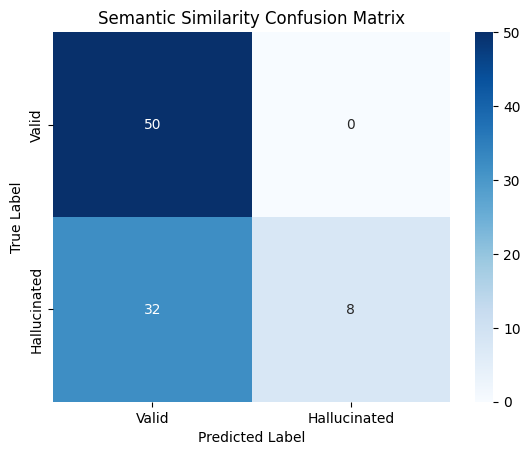

In [7]:
cm = confusion_matrix(y_true, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Valid", "Hallucinated"],
    yticklabels=["Valid", "Hallucinated"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Semantic Similarity Confusion Matrix")
plt.show()


## ROC-AUC Analysis

Although the system uses a fixed threshold, ROC-AUC evaluates
the ranking quality of similarity scores.


In [9]:
auc = roc_auc_score(y_true, 1 - res_df["hallucination_score"])
auc


0.458

## Performance by Hallucination Type

We analyze recall per hallucination type to understand
which error categories semantic similarity can detect.


In [10]:
type_recall = (
    res_df[res_df["label_binary"] == 1]
    .groupby("hallucination_type")["predicted"]
    .mean()
    .sort_values(ascending=False)
)

type_recall


hallucination_type
off_topic          1.0
wrong_entity       0.5
added_fact         0.2
fabricated_stat    0.0
negation           0.0
fake_citation      0.0
Name: predicted, dtype: float64

## Threshold Sensitivity Analysis

We sweep similarity thresholds to observe trade-offs
between precision and recall.


In [11]:
thresholds = np.linspace(0.4, 0.9, 25)
rows = []

for t in thresholds:
    preds = (res_df["max_similarity"] < t).astype(int)
    rows.append({
        "threshold": t,
        "precision": precision_score(y_true, preds),
        "recall": recall_score(y_true, preds),
        "f1": f1_score(y_true, preds),
    })

th_df = pd.DataFrame(rows)


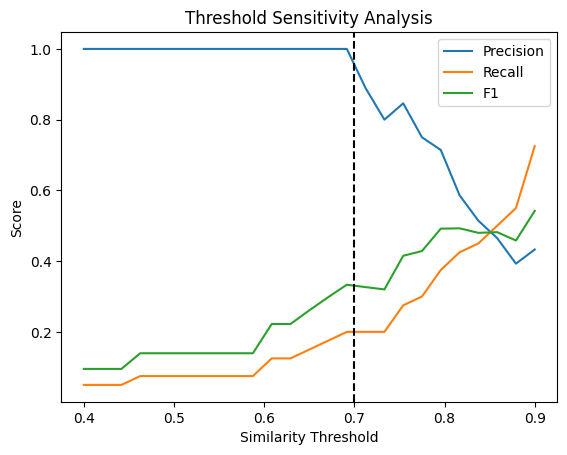

In [12]:
plt.plot(th_df["threshold"], th_df["precision"], label="Precision")
plt.plot(th_df["threshold"], th_df["recall"], label="Recall")
plt.plot(th_df["threshold"], th_df["f1"], label="F1")

plt.axvline(0.7, color="black", linestyle="--")
plt.xlabel("Similarity Threshold")
plt.ylabel("Score")
plt.title("Threshold Sensitivity Analysis")
plt.legend()
plt.show()


## Error Analysis

We inspect false positives and false negatives to
understand why semantic similarity fails in certain cases.


In [13]:
false_positives = res_df[(y_true == 0) & (y_pred == 1)]
false_negatives = res_df[(y_true == 1) & (y_pred == 0)]

len(false_positives), len(false_negatives)


(0, 32)